In [1]:
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import copy
import random
import sys
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

- `x` $\in \mathbb{R}^{N \times L \times H_{in}}$, where $H_{in}: $`in_size` is a **parameter to be given**

- `out` $\in \mathbb{R}^{N \times L \times H_{out}}$, where $H_{out}: $`hidden_size` is a **parameter to be given**

- `h` is a tuple containing two tensors of interest: `(hout, c)`. 

- `hout` $\in \mathbb{R}^{1 \times N \times H_{out}}$, if the `num_layers` LSTM parameter is 1 (which it is by default)

- `last_hidden_states` $\in \mathbb{R}^{N \times H_{out}}$, picks **the last sequence from** `out`

- `final` $\in \mathbb{R}^{N \times P}$

and where:


- $N$: Batch size
- $L$: Sequence Length
- $H_{in}$: `in_size` is the number of input dimensions (features), in other words, multivariate or univariate input ($H_{in}=1$ for univariate input). **This is a parameter**
- $H_{out}$: `hidden_size`. **This is a parameter**
- $P$: `out_size` is the output of the linear layer, and corresponds to multivariate or univariate prediction. **This is a parameter**

In [2]:
class LSTM(nn.Module):

    def __init__(self,
                 hidden_size,
                 in_size = 1,
                 out_size = 1):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size = in_size,
            hidden_size = hidden_size,
            batch_first = True)
        self.fc = nn.Linear(hidden_size, out_size)

    def forward(self, x, h = None):
        out, h = self.lstm(x, h)
        last_hidden_states = out[:, -1]
        final = self.fc(last_hidden_states)
        return final, h

In [3]:
def sliding_window(ts, features):
    X = []
    Y = []

    for i in range(features + 1, len(ts) + 1):
        X.append(ts[i - (features + 1):i - 1])
        Y.append([ts[i - 1]])

    return X, Y

def get_ni_timeseries():
    dir_path = ".."
    df = pd.read_csv(f'{dir_path}/data/NI_hourly.csv')
    ts = df['NI_MW'].astype(int).values.reshape(-1, 1)[-3000:]
    return ts

def get_training_datasets(ts, features, test_len):
    X, Y = sliding_window(ts, features)

    X_train, Y_train, X_test, Y_test = X[0:-test_len],\
                                       Y[0:-test_len],\
                                       X[-test_len:],\
                                       Y[-test_len:]

    train_len = round(len(ts) * 0.7)

    X_train, X_val, Y_train, Y_val = X_train[0:train_len],\
                                     X_train[train_len:],\
                                     Y_train[0:train_len],\
                                     Y_train[train_len:]

    x_train = torch.tensor(data = X_train).float()
    y_train = torch.tensor(data = Y_train).float()

    x_val = torch.tensor(data = X_val).float()
    y_val = torch.tensor(data = Y_val).float()

    x_test = torch.tensor(data = X_test).float()
    y_test = torch.tensor(data = Y_test).float()

    return x_train, x_val, x_test,\
           y_train.squeeze(1), y_val.squeeze(1), y_test.squeeze(1)

# Plot the dataset

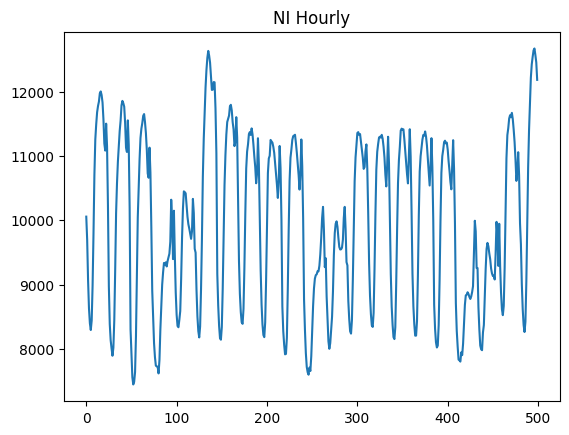

In [4]:
plt.title('NI Hourly')
plt.plot(get_ni_timeseries()[:500])
plt.show()

# Set random seed for reproducibility

In [5]:
random.seed(1)
torch.manual_seed(1)

# Define parameters

In [6]:
features = 240 # sliding window size
test_ts_len = 300 # length of test dataset
lstm_hidden_size = 24 # size of LSTM hidden state

learning_rate = 0.02 # Optimizer learning rate
training_epochs = 100

# Prepare dataset for training, validation and test

In [7]:
ts = get_ni_timeseries()
scaler = MinMaxScaler()
scaled_ts = scaler.fit_transform(ts)
x_train, x_val, x_test, y_train, y_val, y_test =\
    get_training_datasets(scaled_ts, features, test_ts_len)

/tmp/ipykernel_141328/3262224137.py:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  x_train = torch.tensor(data = X_train).float()


# Shapes of datasets

If `dataloader` is not used, then $N = 2100$ **for this example**

In [8]:
print(f"x_train: {x_train.shape}, x_val: {x_val.shape}, x_test: {x_test.shape}")

x_train: torch.Size([2100, 240, 1]), x_val: torch.Size([360, 240, 1]), x_test: torch.Size([300, 240, 1])


$Y \in \mathbb{R}^{N \times H_{in}}$

In [12]:
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")

y_train: torch.Size([2100, 1]), y_val: torch.Size([360, 1]), y_test: torch.Size([300, 1])


In [11]:
# Create a dataset and dataloader
dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Initialize model

In [14]:
model = LSTM(hidden_size = lstm_hidden_size)
model.train()

LSTM(
  (lstm): LSTM(1, 24, batch_first=True)
  (fc): Linear(in_features=24, out_features=1, bias=True)
)

# Define optimizer and loss function

In [15]:
optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)
mse_loss = torch.nn.MSELoss()

# Training loop

- The LSTM model receives as input a tensor `inputs` $\in \mathbb{R}^{N \times L \times H_{in}}$, where in this case $N = 32$ was set when the `DataLoader` class was invoked

- As mentioned up in this notebook, `predicition` $\in \mathbb{R}^{N \times H_{out}}$, and `hout` $\in \mathbb{R}^{N \times H_{out}}$

In [19]:
best_model = None
min_val_loss = sys.maxsize

training_loss = []
validation_loss = []

for t in range(training_epochs):
    for batch_idx, (inputs, labels) in enumerate(dataloader):
        prediction, hout = model(inputs)

        print(f"predictions shape: {prediction.shape}")
        print(f"hstate shape: {hout[0].shape}")
        print(f"labels shape: {labels.shape}")

        loss = mse_loss(prediction, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        val_prediction, _ = model(x_val)
        val_loss = mse_loss(val_prediction, y_val)

        training_loss.append(loss.item())
        validation_loss.append(val_loss.item())

        if val_loss.item() < min_val_loss:
            best_model = copy.deepcopy(model)
            min_val_loss = val_loss.item()

        if t % 10 == 0:
            print(f'epoch {t}: train - {round(loss.item(), 4)}, '
                f'val: - {round(val_loss.item(), 4)}')

predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size([32, 1])
epoch 0: train - 0.0005, val: - 0.0007
predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size([32, 1])
epoch 0: train - 0.0005, val: - 0.0009
predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size([32, 1])
epoch 0: train - 0.0006, val: - 0.001
predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size([32, 1])
epoch 0: train - 0.0005, val: - 0.0011
predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size([32, 1])
epoch 0: train - 0.0005, val: - 0.0012
predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size([32, 1])
epoch 0: train - 0.0004, val: - 0.0013
predictions shape: torch.Size([32, 1])
hstate shape: torch.Size([1, 32, 24])
labels shape: torch.Size

# Evaluate on test set

In [13]:
best_model.eval()
with torch.no_grad():
    _, h_list = best_model(x_val)
    # warm hidden and cell state
    h = tuple([(h[-1, -1, :]).unsqueeze(-2).unsqueeze(-2)
               for h in h_list])

    predicted = []
    for test_seq in x_test.tolist():
        x = torch.Tensor(data = [test_seq])
        # passing hidden state and cell through each iteration
        y, h = best_model(x, h)
        unscaled = scaler.inverse_transform(
            np.array(y.item()).reshape(-1, 1))[0][0]
        predicted.append(unscaled)

real = scaler.inverse_transform(y_test.tolist())

# Plot forecast results

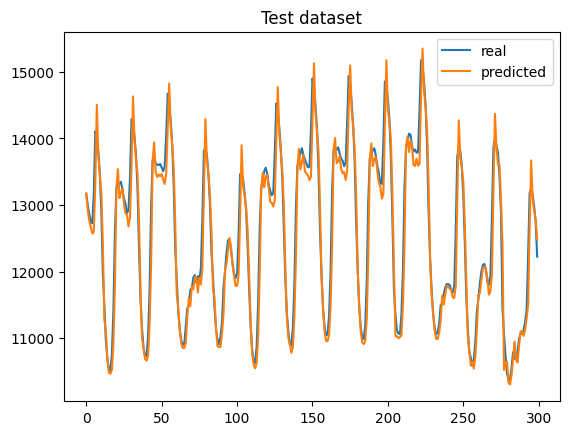

In [14]:
plt.title("Test dataset")
plt.plot(real, label = 'real')
plt.plot(predicted, label = 'predicted')
plt.legend()
plt.show()

# Plot training loss vs epochs

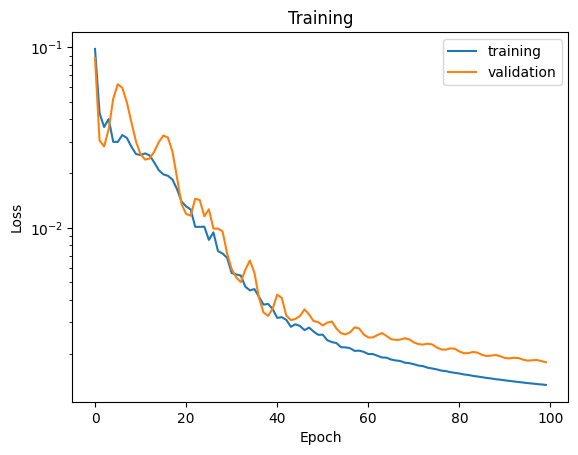

In [15]:

plt.title('Training')
plt.yscale('log')
plt.plot(training_loss, label = 'training')
plt.plot(validation_loss, label = 'validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()